In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [254]:
#1: Load all datasets 
#import Census apportionment data
df_census = pd.read_excel("C:/Users/NFCC-1/Downloads/apportionment-2020-table01.xlsx")
#importing the CDC Places dataset
df_cdc = pd.read_csv("C:/Users/NFCC-1/Downloads/PLACES__Local_Data_for_Better_Health__County_Data__2025_release.csv")
#import insurance dataset
df_insurance=pd.read_csv("C:/Users/NFCC-1/Downloads/insurance.csv")

In [255]:
df_census.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   U.S. Department of Commerce  55 non-null     object
 1   Unnamed: 1                   52 non-null     object
 2   Unnamed: 2                   52 non-null     object
 3   Unnamed: 3                   51 non-null     object
dtypes: object(4)
memory usage: 1.8+ KB


In [256]:
df_census.head()

,U.S. Department of Commerce,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,U.S. Census Bureau,NaN,NaN,NaN
1,Table 1. APPORTIONMENT POPULATION AND NUMBER O...,NaN,NaN,NaN
2,STATE,"APPORTIONMENT POPULATION \n(APRIL 1, 2020)",NUMBER OF APPORTIONED REPRESENTATIVES BASED ON...,CHANGE FROM \n2010 CENSUS APPORTIONMENT
3,Alabama,5030053,7,0
4,Alaska,736081,1,0


In [257]:
#2: Cleaning Census datasets
#droping the first two rows.
df_census= df_census.drop([0, 1])
#droping columns 2 and 3
df_census = df_census.drop(df_census.columns[[2,3]], axis=1)
#rename the columns State and Population
df_census = df_census.rename(columns ={"APPORTIONMENT POPULATION \n(APRIL 1, 2020)": "Population"})
df_census.columns.values[0] = "State"
df_census.columns.values[1] = "Population"
#drop uncessary rows 
df_census = df_census.drop([2,53,54])
#reset the index number
df_census = df_census.reset_index(drop=True)
#make index number start with 1 instead of 0
df_census.index = df_census.index + 1
#export dataset as csv file
df_census.to_csv("/Users/NFCC-1/Downloads/cleaned_cens.csv", index=False)

In [258]:
df_census.head()

,State,Population
1,Alabama,5030053
2,Alaska,736081
3,Arizona,7158923
4,Arkansas,3013756
5,California,39576757


In [259]:
df_cdc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229298 entries, 0 to 229297
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Year                        229298 non-null  int64  
 1   StateAbbr                   229298 non-null  object 
 2   StateDesc                   229298 non-null  object 
 3   LocationName                229218 non-null  object 
 4   DataSource                  229298 non-null  object 
 5   Category                    229298 non-null  object 
 6   Measure                     229298 non-null  object 
 7   Data_Value_Unit             229298 non-null  object 
 8   Data_Value_Type             229298 non-null  object 
 9   Data_Value                  229232 non-null  float64
 10  Data_Value_Footnote_Symbol  80 non-null      object 
 11  Data_Value_Footnote         80 non-null      object 
 12  Low_Confidence_Limit        229232 non-null  float64
 13  High_Confidenc

In [260]:
#3: Cleaning CDC datasets
# From the large CDC data we kept only this measurement
df_cdc = df_cdc[df_cdc['MeasureId'].isin(['CSMOKING', 'OBESITY', 'DIABETES'])]
# we kept only the columns will helps us with this project
df_cdc = df_cdc[['StateDesc', 'StateAbbr', 'MeasureId', 'Data_Value']]
#what I did here is grouping rows that have same state and same measure and calculate th average of data_value for each group
df_cdc =df_cdc.groupby(['StateDesc', 'MeasureId'])['Data_Value'].mean().reset_index()
#converting to a wide format(each state has one row and each measureId now is a column and each measureId has average value
df_cdc=df_cdc.pivot(index='StateDesc', columns='MeasureId', values='Data_Value').reset_index()
df_cdc.columns.name= None
#rename columns
df_cdc=df_cdc.rename(columns={'StateDesc': 'State', 'OBESITY': 'Obesity_rate', 'CSMOKING': 'Smoking_rate', 'DIABETES':'Diabetes_rate'})
#export dataset as csv file
df_cdc.to_csv("/Users/NFCC-1/Downloads/cleaned_cdc.csv", index=False)

In [261]:
df_cdc.head()

,State,Smoking_rate,Diabetes_rate,Obesity_rate
0,Alabama,17.720896,15.358209,41.828358
1,Alaska,19.386667,10.960000,35.533333
2,Arizona,14.263333,12.190000,33.263333
3,Arkansas,18.374667,13.854000,41.015333
4,California,12.413793,11.183621,29.873276


In [262]:
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [263]:
# Load the cleaned datasets
cleaned_cens_df=pd.read_csv("/Users/NFCC-1/Downloads/cleaned_cens.csv")
cleaned_cdc_df=pd.read_csv("/Users/NFCC-1/Downloads/cleaned_cdc.csv")

In [264]:
cleaned_cens_df.head()

,State,Population
0,Alabama,5030053
1,Alaska,736081
2,Arizona,7158923
3,Arkansas,3013756
4,California,39576757


In [265]:
cleaned_cdc.head()

,State,Smoking_rate,Diabetes_rate,Obesity_rate
0,Alabama,17.720896,15.358209,41.828358
1,Alaska,19.386667,10.960000,35.533333
2,Arizona,14.263333,12.190000,33.263333
3,Arkansas,18.374667,13.854000,41.015333
4,California,12.413793,11.183621,29.873276


In [266]:
#4: Create a state Abbreviation look up
state_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}
# add abbreviation to census dataset
cleaned_cens_df['state_abbr'] = cleaned_cens_df['State'].map(state_abbr)
cleaned_cens_df= cleaned_census.dropna(subset=['state_abbr'])
#Create a population Dictionary
pop_dict = dict(zip(cleaned_cens_df['state_abbr'], cleaned_cens_df['Population']))
#5: Map regions to states
region_states = {
    'northeast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA', 'OH', 'MI', 'IN', 'IL', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS'],
    'southeast': ['DE', 'MD', 'VA', 'WV', 'KY', 'TN', 'NC', 'SC', 'GA', 'FL', 'AL', 'MS', 'AR', 'LA'],
    'northwest': ['WA', 'OR', 'ID', 'MT', 'WY', 'AK'],
    'southwest': ['CA', 'NV', 'UT', 'AZ', 'NM', 'CO', 'OK', 'TX', 'HI']
}
#here we need to assign each person with state so we took region name and look up states belong to that region
#and get the population for those states and turn them to probabilities larger the population is higher probability
#the state has higher probabilty would be assign to that person
def assign_state_weighted(region):
    states_in_region = region_states[region]
    pops = [pop_dict[state] for state in states_in_region]
    weights = np.array(pops) / sum(pops)
    return np.random.choice(states_in_region, p=weights)
   
# We apply this function to insurance dataset
df_insurance['state_abbr'] = df_insurance['region'].apply(assign_state_weighted)
#Add full state name
abbr_to_name = dict(zip(cleaned_cens_df['state_abbr'], cleaned_cens_df['State']))
df_insurance['State'] = df_insurance['state_abbr'].map(abbr_to_name)
#Merge insurance dataset with cleaned cdc
final_df = df_insurance.merge(cleaned_cdc, on='State', how='left')

In [267]:
final_df.isnull().sum()

age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
state_abbr        0
State             0
Smoking_rate     52
Diabetes_rate    52
Obesity_rate     52
dtype: int64

In [268]:
#After we merged the datasets and we added states to each region we faced a problem missing values in two state(Kentucky and Pennsylvania
#the resaon behind missing values is the measuresid we picked from cdc datasets those state are not included.
#We filled the mising values with regional average 
for col in ['Smoking_rate', 'Obesity_rate', 'Diabetes_rate']:
    final_df[col] = final_df.groupby('region')[col].transform(lambda x: x.fillna(x.mean()))
    final_df[col] = final_df[col].round(2)
#final_df.to_csv("/Users/NFCC-1/Downloads/final_cleaned_df.csv", index=False)


In [269]:
#Laod the final cleaned insurance dataset
final_draft=pd.read_csv("/Users/NFCC-1/Downloads/final_cleaned_df.csv")

In [270]:
final_draft.head()

,age,sex,bmi,children,smoker,region,charges,state_abbr,State,Smoking_rate,Diabetes_rate,Obesity_rate
0,19,female,27.900,0,yes,southwest,16884.92400,CA,California,12.41,11.18,29.87
1,18,male,33.770,1,no,southeast,1725.55230,KY,Kentucky,16.67,13.63,38.07
2,28,male,33.000,3,no,southeast,4449.46200,LA,Louisiana,19.89,15.34,42.15
3,33,male,22.705,0,no,northwest,21984.47061,OR,Oregon,13.76,11.53,35.41
4,32,male,28.880,0,no,northwest,3866.85520,AK,Alaska,19.39,10.96,35.53


In [271]:
final_draft.isnull().sum()

age              0
sex              0
bmi              0
children         0
smoker           0
region           0
charges          0
state_abbr       0
State            0
Smoking_rate     0
Diabetes_rate    0
Obesity_rate     0
dtype: int64

In [272]:
# =============================================
# EDA - REGION & STATE COMPARISONS
# =============================================
print("REGION & STATE COMPARISONS")

# 1. Region Summary - All metrics at once
region_summary = final_draft.groupby("region").agg({
    "charges": ["mean", "min", "max", "std"],
    "Smoking_rate": ["mean", "min", "max"],
    "Obesity_rate": ["mean", "min", "max"],
    "Diabetes_rate": ["mean", "min", "max"],
    "age": ["mean"],
    "bmi": ["mean"],
    "children": ["mean"]
}).round(2)

print("\nREGION SUMMARY:")
print(region_summary)

REGION & STATE COMPARISONS

REGION SUMMARY:
            charges                              Smoking_rate                \
               mean      min       max       std         mean    min    max   
region                                                                        
northeast  13406.38  1694.80  58571.07  11255.80        14.72  10.96  19.09   
northwest  12417.58  1621.34  60021.40  11072.28        13.40  12.17  19.39   
southeast  14735.41  1121.87  63770.43  13971.10        16.67  12.74  21.10   
southwest  12346.94  1241.56  52590.83  11557.18        13.82  10.02  18.81   

          Obesity_rate               Diabetes_rate                  age  \
                  mean    min    max          mean    min    max   mean   
region                                                                    
northeast        35.41  27.96  39.74         10.92   8.43  12.54  39.27   
northwest        34.45  33.39  35.53         10.74  10.31  11.53  39.20   
southeast        38.07  34.

In [273]:
# 2. State Summary - Top metrics
state_summary = final_draft.groupby("State").agg({
    "charges": "mean",
    "Smoking_rate": "mean",
    "Obesity_rate": "mean",
    "Diabetes_rate": "mean"
}).round(2)

print("\nTOP 5 HIGHEST PREMIUM STATES:")
print(state_summary.nlargest(5, "charges"))

print("\nTOP 5 LOWEST PREMIUM STATES:")
print(state_summary.nsmallest(5, "charges"))



TOP 5 HIGHEST PREMIUM STATES:
                 charges  Smoking_rate  Obesity_rate  Diabetes_rate
State                                                              
Delaware        25213.45         13.25         37.03          12.27
Louisiana       21098.91         19.89         42.15          15.34
Indiana         20270.08         17.39         39.74          12.42
Utah            18826.43         10.02         31.68           9.93
South Carolina  18763.09         15.76         39.06          14.97

TOP 5 LOWEST PREMIUM STATES:
              charges  Smoking_rate  Obesity_rate  Diabetes_rate
State                                                           
Nebraska      1704.70         14.56         39.57          11.04
North Dakota  3481.87         15.32         38.83          10.91
Nevada        5885.99         16.43         34.59          11.67
South Dakota  7367.20         17.91         37.02          12.29
Colorado      8209.90         12.67         27.09           9.60


In [274]:
# 3. Find patterns - Which states have high smoking AND high charges?
print("\nSTATES WITH HIGH SMOKING & HIGH CHARGES:")
high_smoking = state_summary[state_summary["Smoking_rate"] > state_summary["Smoking_rate"].mean()]
high_charges = high_smoking[high_smoking["charges"] > high_smoking["charges"].mean()]
print(high_charges.sort_values("charges", ascending=False).head(5))


STATES WITH HIGH SMOKING & HIGH CHARGES:
                 charges  Smoking_rate  Obesity_rate  Diabetes_rate
State                                                              
Louisiana       21098.91         19.89         42.15          15.34
Indiana         20270.08         17.39         39.74          12.42
South Carolina  18763.09         15.76         39.06          14.97
North Carolina  16052.62         15.74         37.44          12.58
Minnesota       15920.56         15.41         36.90          10.54


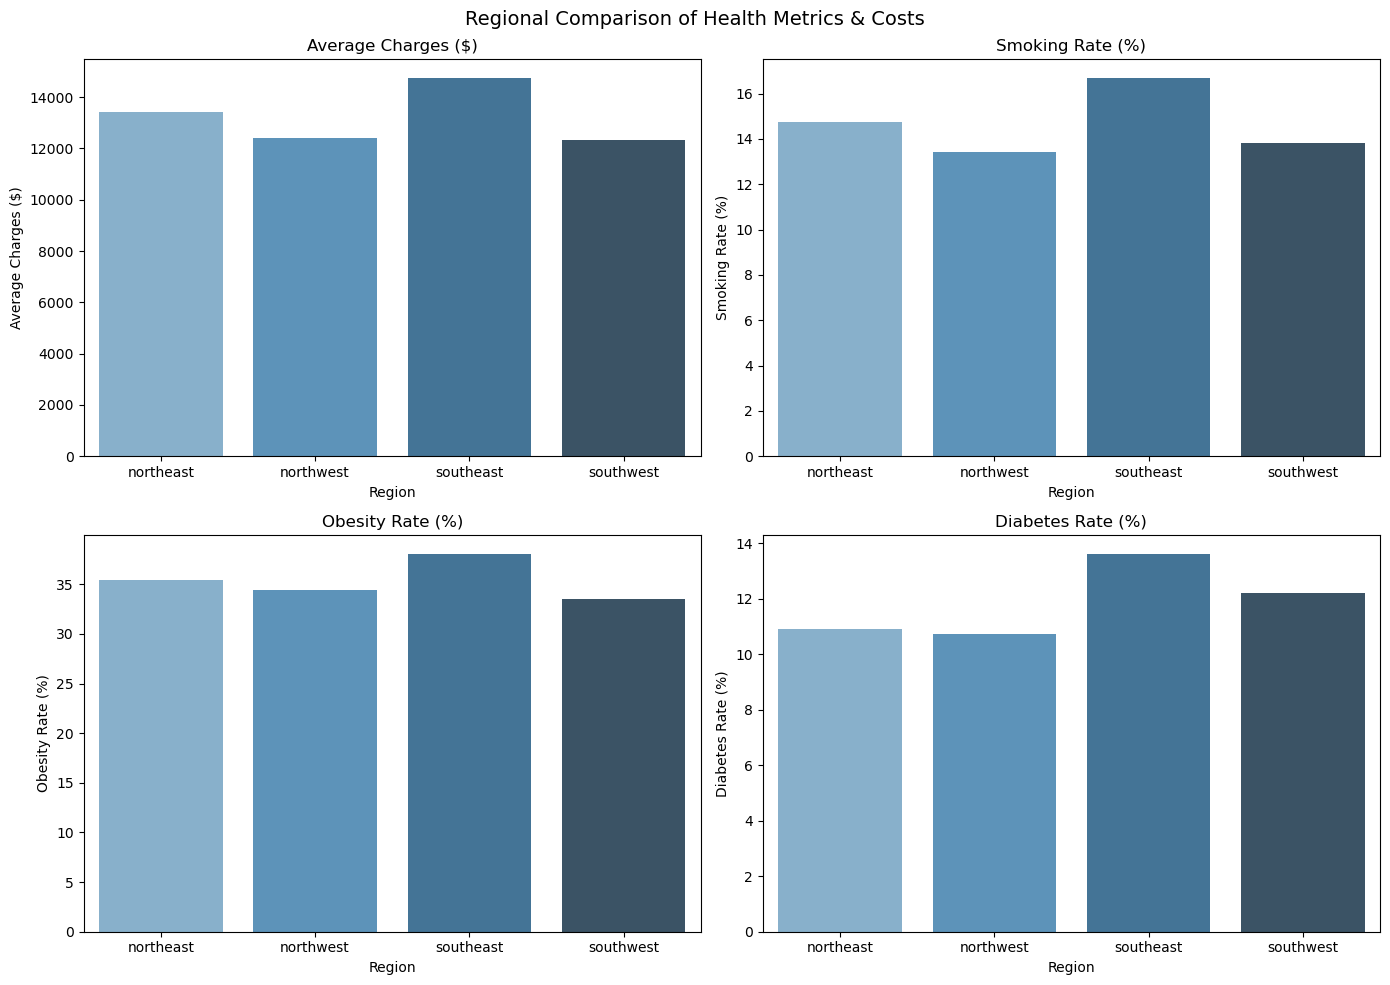

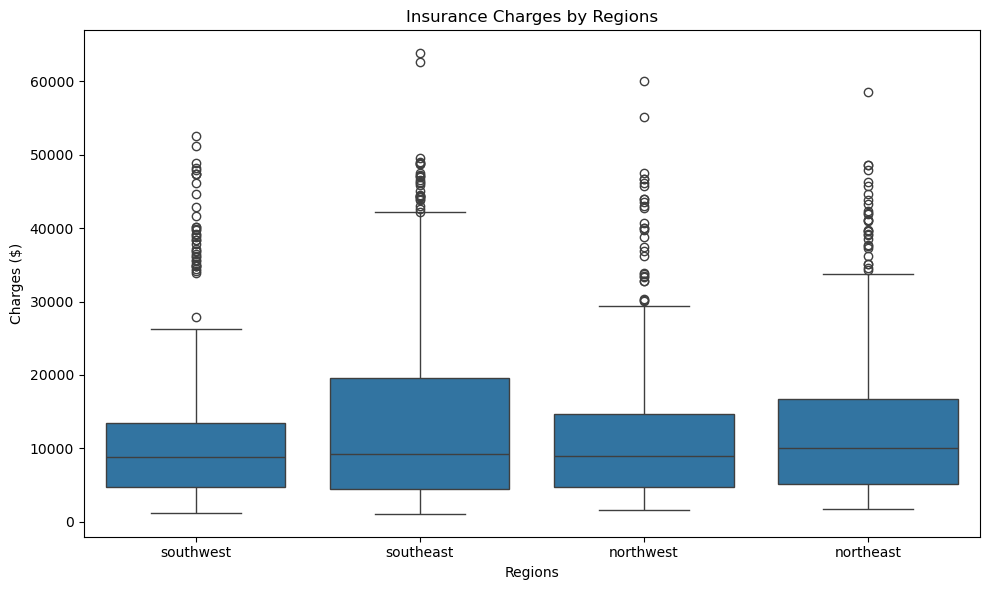

In [275]:
# =============================================
# EDA VISUALIZATIONS
# =============================================
# 1. Region comparison - Bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Regional Comparison of Health Metrics & Costs", fontsize=14)

metrics = [
    ("charges", "Average Charges ($)", axes[0, 0]),
    ("Smoking_rate", "Smoking Rate (%)", axes[0, 1]),
    ("Obesity_rate", "Obesity Rate (%)", axes[1, 0]),
    ("Diabetes_rate", "Diabetes Rate (%)", axes[1, 1])
]

region_avg = final_draft.groupby("region")[["charges", "Smoking_rate", "Obesity_rate", "Diabetes_rate"]].mean().reset_index()

for col, label, ax in metrics:
    sns.barplot(data=region_avg, x="region", y=col, ax=ax, palette="Blues_d")
    ax.set_title(label)
    ax.set_xlabel("Region")
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

# =============================================
# PLOT 1: Boxplot - Charges by Region
# =============================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_draft, x='region', y='charges')
plt.title('Insurance Charges by Regions')
plt.xlabel('Regions')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

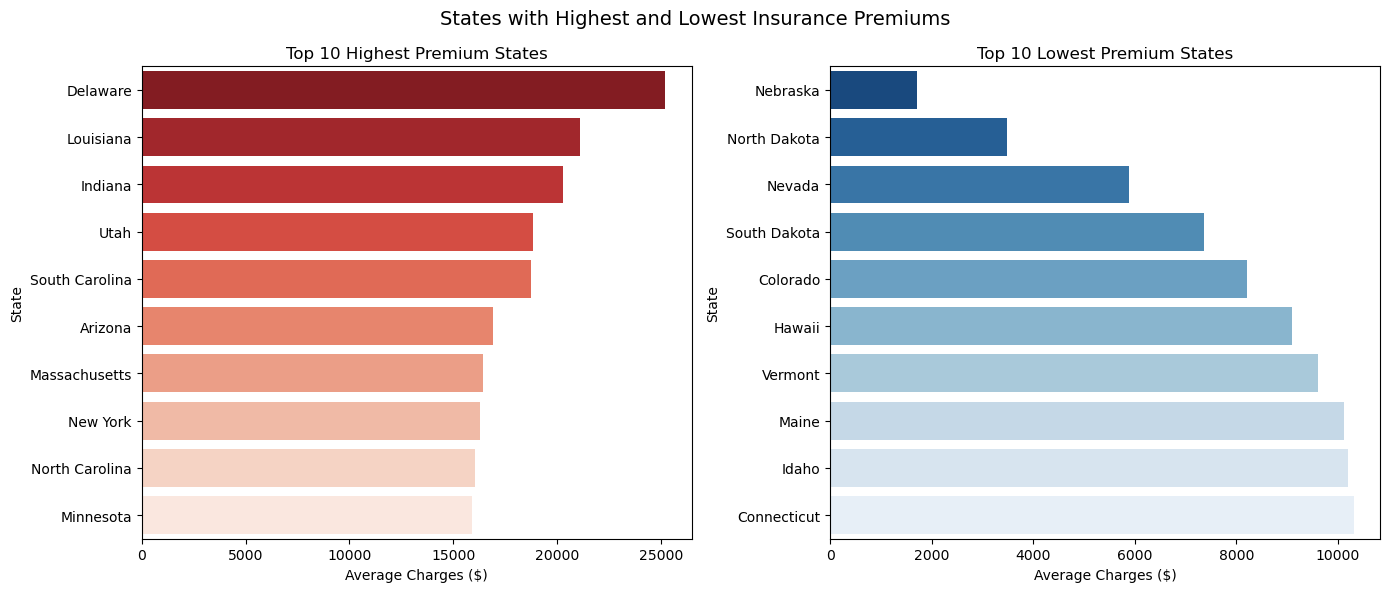

In [276]:
# 2. State rankings - Top/Bottom states
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("States with Highest and Lowest Insurance Premiums", fontsize=14)

state_avg = final_draft.groupby("State")["charges"].mean().sort_values()
# Top 10
top_states = state_avg.nlargest(10).reset_index()
sns.barplot(data=top_states, y="State", x="charges", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top 10 Highest Premium States")
axes[0].set_xlabel("Average Charges ($)")

# Bottom 10
bottom_states = state_avg.nsmallest(10).reset_index()
sns.barplot(data=bottom_states, y="State", x="charges", ax=axes[1], palette="Blues_r")
axes[1].set_title("Top 10 Lowest Premium States")
axes[1].set_xlabel("Average Charges ($)")

plt.tight_layout()
plt.show()

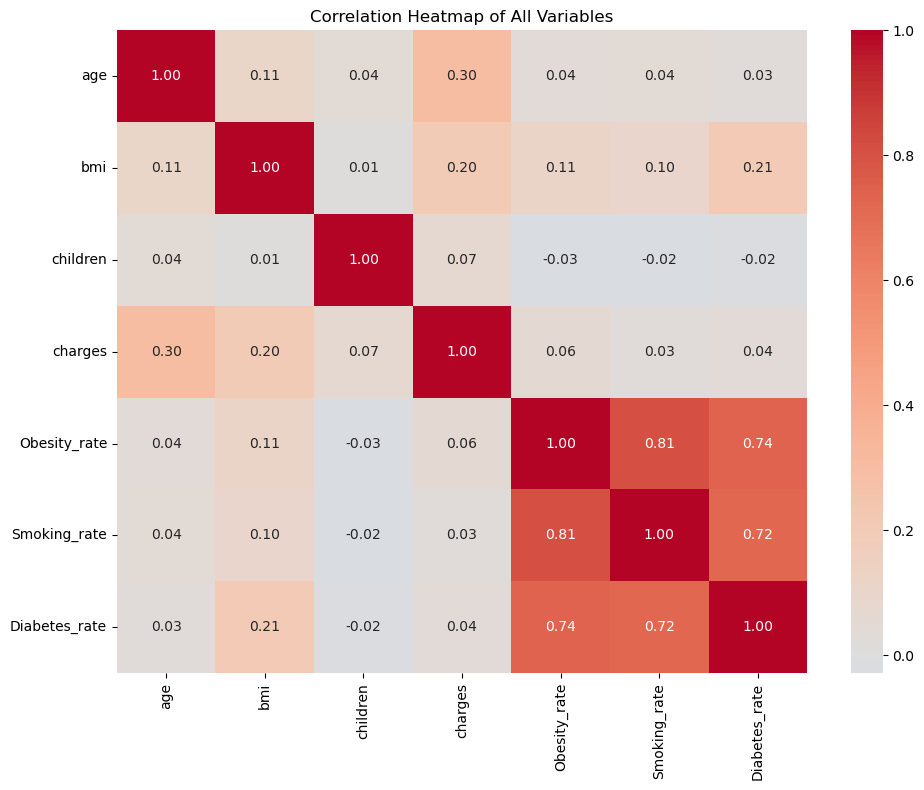

In [277]:
# 3. Correlation between health metrics and charges
numeric_cols = ['age', 'bmi', 'children', 'charges', 'Obesity_rate', 'Smoking_rate', 'Diabetes_rate']
corr = final_df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of All Variables')
plt.tight_layout()
plt.show()


Female profile records: 4 regions
      region       charges
0  northeast  26347.576629
1  northwest  29180.890981
2  southeast  26761.542186
3  southwest  25393.635500

Male profile records: 4 regions
      region       charges
0  northeast  30203.001117
1  northwest  26351.224663
2  southeast  27563.306526
3  southwest  27874.887246


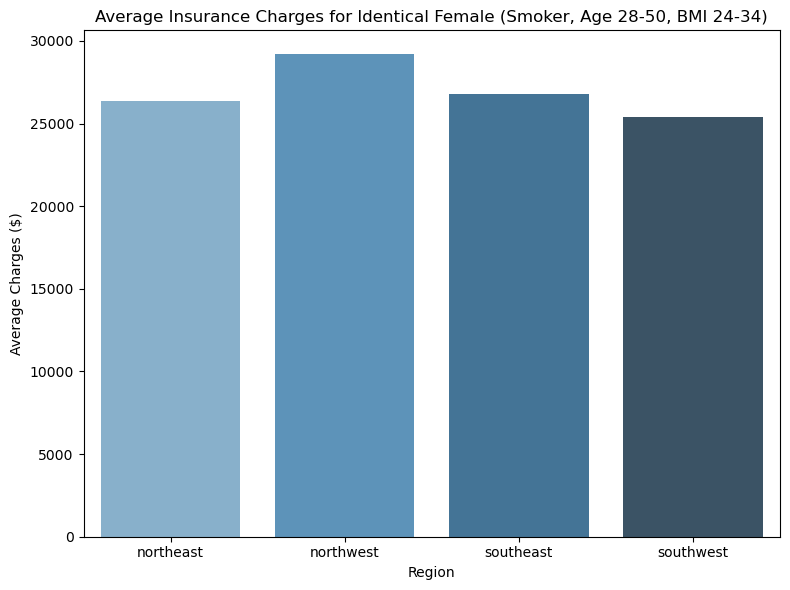

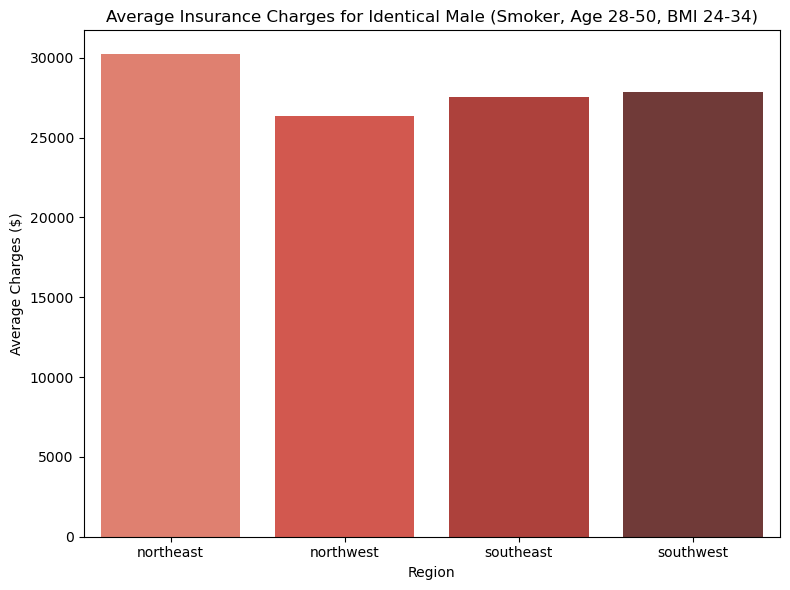

In [278]:
# =============================================
def analyze_identical_person(sex):
    """Analyze average charges for identical profile by region for a given sex"""
    profile = final_draft[
        (final_draft['age'].between(28, 50)) &
        (final_draft['bmi'].between(24, 34)) &
        (final_draft['smoker'] == 'yes') &
        (final_draft['sex'] == sex)
    ]
    return profile.groupby('region')['charges'].mean().reset_index()

# Store results for both sexes
profile_data = {}
for sex in ['female', 'male']:
    profile_data[sex] = analyze_identical_person(sex)
    print(f"\n{sex.title()} profile records: {len(profile_data[sex])} regions")
    print(profile_data[sex])

# Plot for FEMALE
plt.figure(figsize=(8, 6))
sns.barplot(data=profile_data['female'], x='region', y='charges', palette="Blues_d")
plt.title('Average Insurance Charges for Identical Female (Smoker, Age 28-50, BMI 24-34)')
plt.xlabel('Region')
plt.ylabel('Average Charges ($)')
plt.tight_layout()
plt.show()
# Plot for MALE
plt.figure(figsize=(8, 6))
sns.barplot(data=profile_data['male'], x='region', y='charges', palette="Reds_d")
plt.title('Average Insurance Charges for Identical Male (Smoker, Age 28-50, BMI 24-34)')
plt.xlabel('Region')
plt.ylabel('Average Charges ($)')
plt.tight_layout()
plt.show()


REGION: SOUTHEAST
southeast: 364 records

              age         bmi    children       charges  Smoking_rate  \
count  364.000000  364.000000  364.000000    364.000000    364.000000   
mean    38.939560   33.355989    1.049451  14735.411438     16.673654   
std     14.164585    6.477648    1.177276  13971.098589      2.083390   
min     18.000000   19.800000    0.000000   1121.873900     12.740000   
25%     26.750000   28.572500    0.000000   4440.886200     15.270000   
50%     39.000000   33.330000    1.000000   9294.131950     15.760000   
75%     51.000000   37.812500    2.000000  19526.286900     17.720000   
max     64.000000   53.130000    5.000000  63770.428010     21.100000   

       Diabetes_rate  Obesity_rate  
count     364.000000    364.000000  
mean       13.623791     38.072582  
std         1.091557      2.397997  
min        11.720000     34.670000  
25%        12.820000     36.350000  
50%        13.630000     38.070000  
75%        14.480000     39.920000  
max

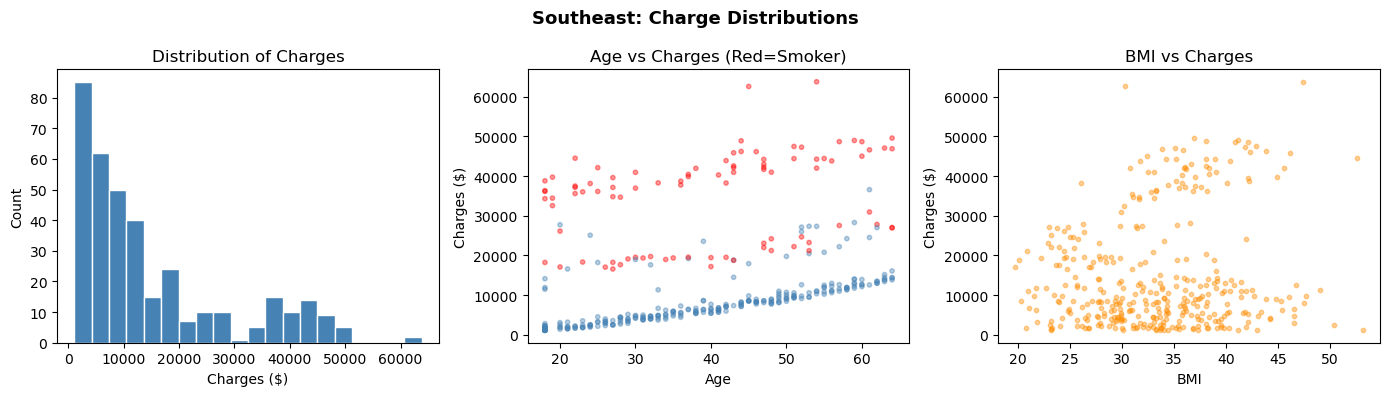

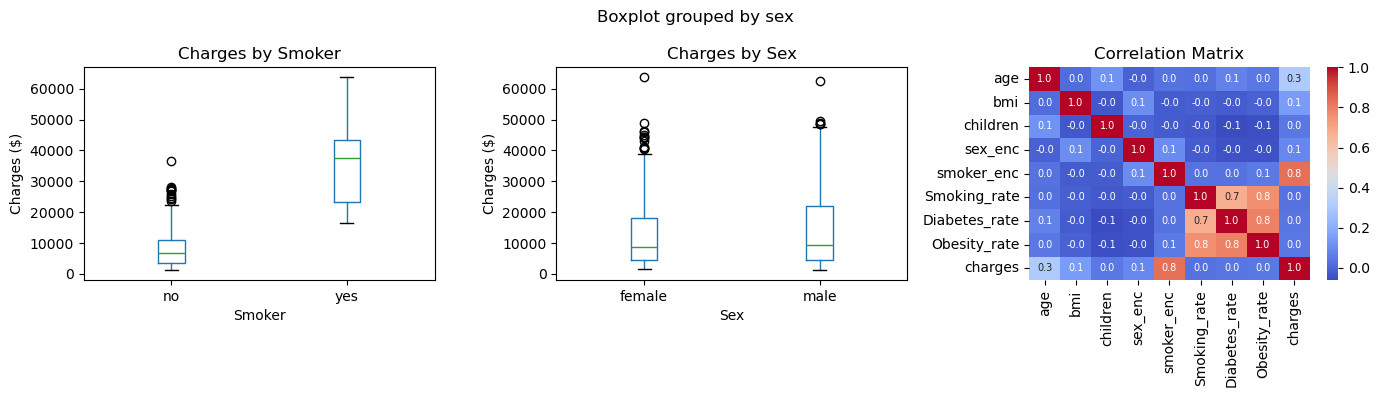


REGION: SOUTHWEST
southwest: 325 records

              age         bmi    children       charges  Smoking_rate  \
count  325.000000  325.000000  325.000000    325.000000    325.000000   
mean    39.455385   30.596615    1.141538  12346.937377     13.818400   
std     13.959886    5.691836    1.275952  11557.179101      1.649104   
min     19.000000   17.400000    0.000000   1241.565000     10.020000   
25%     27.000000   26.900000    0.000000   4751.070000     12.410000   
50%     39.000000   30.300000    1.000000   8798.593000     14.260000   
75%     51.000000   34.600000    2.000000  13462.520000     14.910000   
max     64.000000   47.600000    5.000000  52590.829390     18.810000   

       Diabetes_rate  Obesity_rate  
count     325.000000    325.000000  
mean       12.206000     33.481046  
std         1.253242      3.946147  
min         9.600000     27.090000  
25%        11.180000     29.870000  
50%        12.190000     33.260000  
75%        13.600000     37.580000  
max

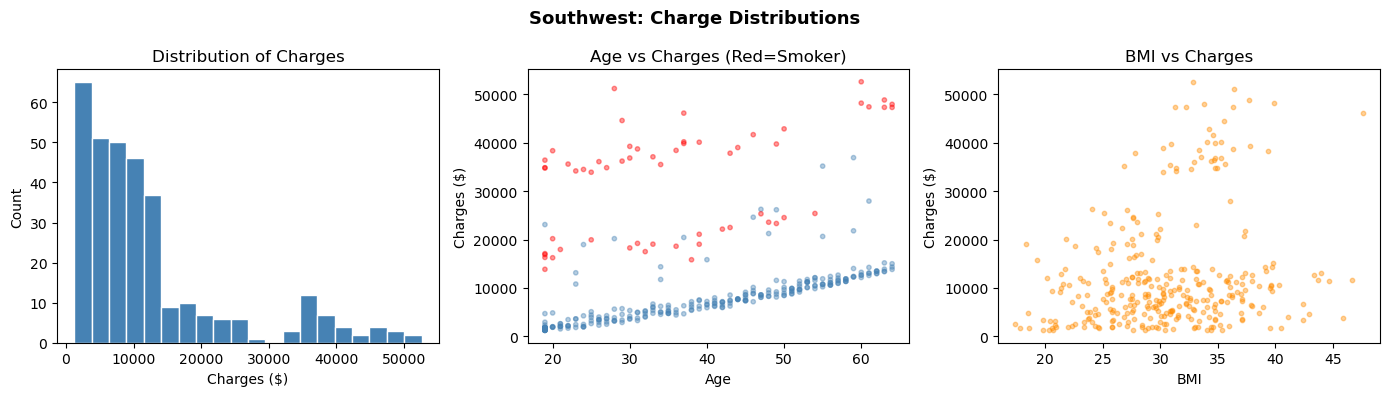

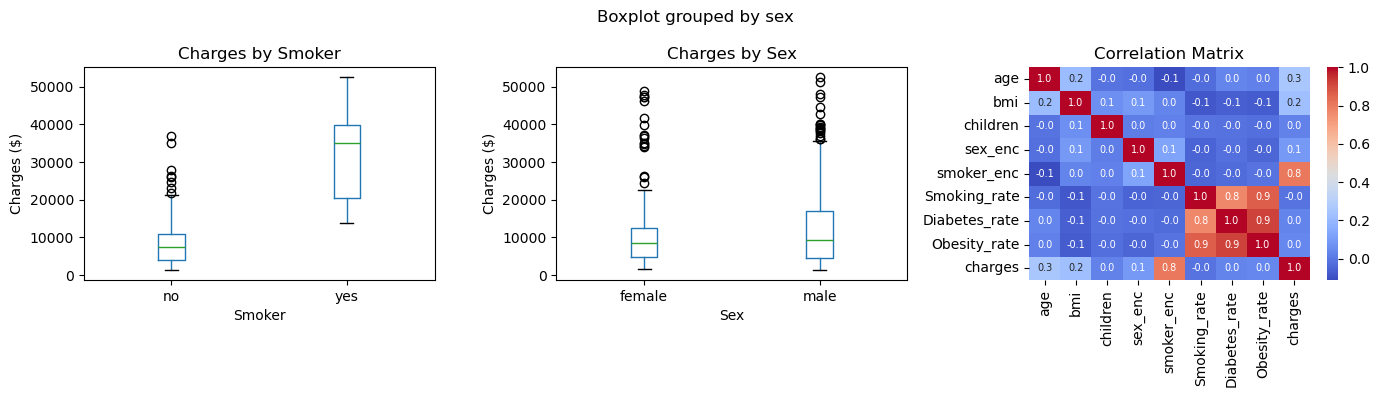


REGION: NORTHEAST
northeast: 324 records

              age         bmi    children       charges  Smoking_rate  \
count  324.000000  324.000000  324.000000    324.000000    324.000000   
mean    39.268519   29.173503    1.046296  13406.384516     14.722315   
std     14.069007    5.937513    1.198949  11255.803066      2.114418   
min     18.000000   15.960000    0.000000   1694.796400     10.960000   
25%     27.000000   24.866250    0.000000   5194.322288     13.360000   
50%     39.500000   28.880000    1.000000  10057.652025     15.240000   
75%     51.000000   32.893750    2.000000  16687.364100     16.220000   
max     64.000000   48.070000    5.000000  58571.074480     19.090000   

       Diabetes_rate  Obesity_rate  
count     324.000000    324.000000  
mean       10.922809     35.409414  
std         1.027877      3.798157  
min         8.430000     27.960000  
25%        10.190000     32.900000  
50%        10.920000     36.900000  
75%        11.580000     38.837500  
max

In [ ]:
# Define regions
REGIONS = ["southeast", "southwest", "northeast", "northwest"]
# ───────────────
# MASTER ANALYSIS LOOP
# ───────────────

for region in REGIONS:
    print(f"\n{'='*60}")
    print(f"REGION: {region.upper()}")
    print('='*60)
    
    # Filter region
    reg_df = final_draft[final_draft["region"] == region].copy()
    print(f"{region}: {len(reg_df)} records\n")
    print(reg_df.describe())
    
    # ───────────────
    # 1. DATA TRENDS
    # ───────────────
    print(f"\n--- {region.title()} Data Trends ---")
    print(f"Average insurance charge: ${reg_df['charges'].mean():,.2f}")
    print(f"Median insurance charge:  ${reg_df['charges'].median():,.2f}")
    print(f"Std deviation of charges: ${reg_df['charges'].std():,.2f}")
    print(f"Average smoking rate:     {reg_df['Smoking_rate'].mean():.2f}")
    print(f"Average diabetes rate:    {reg_df['Diabetes_rate'].mean():.2f}")
    print(f"Average obesity rate:     {reg_df['Obesity_rate'].mean():.2f}")
    
    # ───────────────
    # 2. STATISTICAL ANALYSIS
    # ───────────────
    
    # 2a. T-Test vs others
    other = final_draft[final_draft["region"] != region]["charges"]
    t_stat, p_value = stats.ttest_ind(reg_df["charges"], other)
    print(f"\n[T-Test] {region.title()} vs Other Regions")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {p_value:.4f}")
    print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}")
    
    # 2b. Correlation
    reg_encoded = reg_df.copy()
    le = LabelEncoder()
    reg_encoded["sex_enc"] = le.fit_transform(reg_df["sex"])
    reg_encoded["smoker_enc"] = le.fit_transform(reg_df["smoker"])
    
    corr_vars = ["age", "bmi", "children", "sex_enc", "smoker_enc",
                 "Smoking_rate", "Diabetes_rate", "Obesity_rate", "charges"]
    
    print(f"\n[Correlation with Charges - {region.title()}]")
    print(reg_encoded[corr_vars].corr()["charges"]
          .drop("charges")
          .sort_values(ascending=False)
          .to_string())
    
    # 2c. ANOVA (Smoker vs Non-smoker)
    smoker_charges = reg_df[reg_df["smoker"] == "yes"]["charges"]
    nonsmoker_charges = reg_df[reg_df["smoker"] == "no"]["charges"]
    f_stat, p_anova = stats.f_oneway(smoker_charges, nonsmoker_charges)
    print(f"\n[ANOVA] Smoker vs Non-Smoker charges in {region.title()}")
    print(f"  F-stat: {f_stat:.2f}, p-value: {p_anova:.4e}")
    
    # ───────────────
    # 3. VISUALIZATIONS
    # ───────────────
    
    # Figure 1: Distributions & Relationships
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{region.title()}: Charge Distributions", fontsize=13, fontweight="bold")
    
    axes[0].hist(reg_df["charges"], bins=20, color="steelblue", edgecolor="white")
    axes[0].set_title("Distribution of Charges")
    axes[0].set_xlabel("Charges ($)")
    axes[0].set_ylabel("Count")
    
    colors = reg_df["smoker"].map({"yes": "red", "no": "steelblue"})
    axes[1].scatter(reg_df["age"], reg_df["charges"], c=colors, alpha=0.4, s=10)
    axes[1].set_title("Age vs Charges (Red=Smoker)")
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("Charges ($)")
    
    axes[2].scatter(reg_df["bmi"], reg_df["charges"], alpha=0.4, color="darkorange", s=10)
    axes[2].set_title("BMI vs Charges")
    axes[2].set_xlabel("BMI")
    axes[2].set_ylabel("Charges ($)")
    
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Boxplots & Heatmap
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{region.title()}: Comparisons & Correlations", fontsize=13, fontweight="bold")
    
    reg_df.boxplot(column="charges", by="smoker", ax=axes[0], grid=False)
    plt.sca(axes[0])
    plt.title("Charges by Smoker")
    axes[0].set_xlabel("Smoker")
    axes[0].set_ylabel("Charges ($)")
    
    reg_df.boxplot(column="charges", by="sex", ax=axes[1], grid=False)
    plt.sca(axes[1])
    plt.title("Charges by Sex")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Charges ($)")
    
    sns.heatmap(reg_encoded[corr_vars].corr(), annot=True, fmt=".1f",
                cmap="coolwarm", ax=axes[2], annot_kws={"size": 7})
    axes[2].set_title("Correlation Matrix")
    
    plt.tight_layout()
    plt.show()


--- Cross-Region Comparison Table ---
      region  Avg_Charge  Median_Charge  Avg_Smoking_Rate  Avg_Obesity_Rate  Avg_Diabetes_Rate  Avg_Age  Avg_BMI  Avg_Children
0  northeast    13406.38       10057.65             14.83             35.70              10.96    39.27    29.17          1.05
1  northwest    12417.58        8965.80             13.34             34.40              10.69    39.20    29.20          1.15
2  southeast    14735.41        9294.13             16.63             38.02              13.61    38.94    33.36          1.05
3  southwest    12346.94        8798.59             13.63             33.01              12.03    39.46    30.60          1.14

Comparison table saved to Google Drive


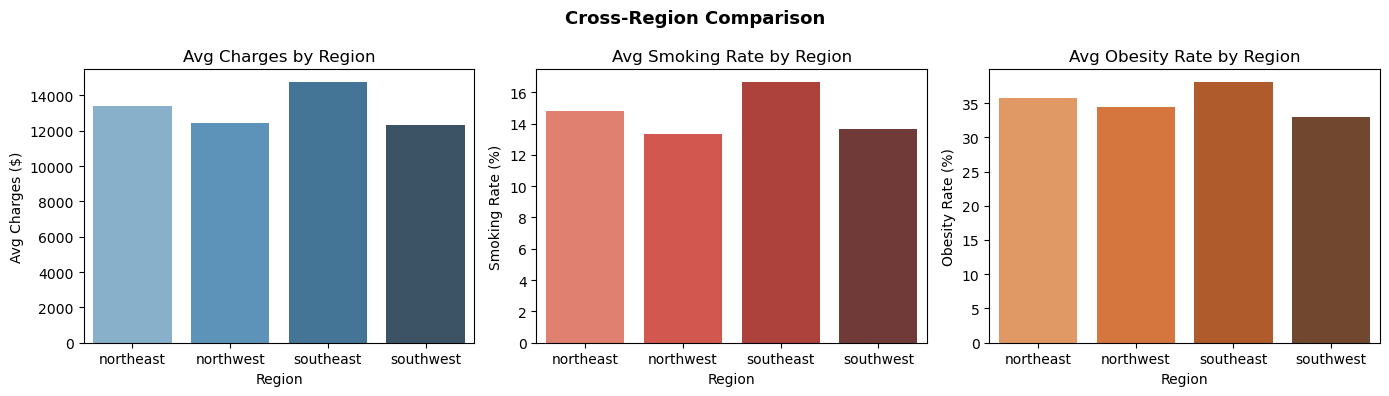

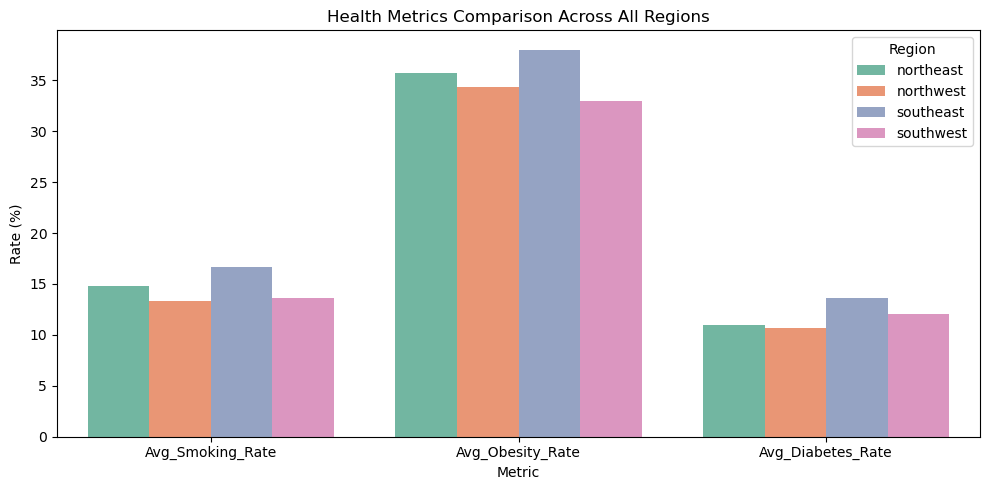


Comparison plots saved to Google Drive

[ANOVA] Charges across all 4 regions
  F-stat: 2.97, p-value: 3.0893e-02
  Significant difference: Yes

[Post-Hoc Dunn Test - p-values]
           northeast  northwest  southeast  southwest
northeast     1.0000     0.7636        1.0     0.2791
northwest     0.7636     1.0000        1.0     1.0000
southeast     1.0000     1.0000        1.0     1.0000
southwest     0.2791     1.0000        1.0     1.0000


In [82]:
# ───────────────
# CROSS-REGION COMPARISON
# ───────────────
# Install scikit-posthocs if not already installed
try:
    from scikit_posthocs import posthoc_dunn
except ImportError:
    %pip install scikit-posthocs
    from scikit_posthocs import posthoc_dunn

import warnings
warnings.filterwarnings("ignore")

# Comparison Table
comparison_table = final_df.groupby("region").agg(
    Avg_Charge=("charges", "mean"),
    Median_Charge=("charges", "median"),
    Avg_Smoking_Rate=("Smoking_rate", "mean"),
    Avg_Obesity_Rate=("Obesity_rate", "mean"),
    Avg_Diabetes_Rate=("Diabetes_rate", "mean"),
    Avg_Age=("age", "mean"),
    Avg_BMI=("bmi", "mean"),
    Avg_Children=("children", "mean")
).round(2).reset_index()

print("\n--- Cross-Region Comparison Table ---")
print(comparison_table.to_string())


#Comparison Visualizations
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Cross-Region Comparison", fontsize=13, fontweight="bold")

sns.barplot(data=comparison_table, x="region", y="Avg_Charge", ax=axes[0], palette="Blues_d")
axes[0].set_title("Avg Charges by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Avg Charges ($)")

sns.barplot(data=comparison_table, x="region", y="Avg_Smoking_Rate", ax=axes[1], palette="Reds_d")
axes[1].set_title("Avg Smoking Rate by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Smoking Rate (%)")

sns.barplot(data=comparison_table, x="region", y="Avg_Obesity_Rate", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Avg Obesity Rate by Region")
axes[2].set_xlabel("Region")
axes[2].set_ylabel("Obesity Rate (%)")

plt.tight_layout()
plt.show()

# Grouped bar chart comparing all metrics
metrics = ["Avg_Smoking_Rate", "Avg_Obesity_Rate", "Avg_Diabetes_Rate"]
comparison_melted = comparison_table.melt(id_vars="region", value_vars=metrics,
                                           var_name="Metric", value_name="Value")
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Value", hue="region", palette="Set2")
plt.title("Health Metrics Comparison Across All Regions")
plt.xlabel("Metric")
plt.ylabel("Rate (%)")
plt.legend(title="Region")
plt.tight_layout()
plt.show()
print("\nComparison plots saved to Google Drive")

#Statistical Comparison
ne = final_df[final_df["region"] == "northeast"]["charges"]
nw = final_df[final_df["region"] == "northwest"]["charges"]
se = final_df[final_df["region"] == "southeast"]["charges"]
sw = final_df[final_df["region"] == "southwest"]["charges"]

f_stat, p_anova = stats.f_oneway(ne, nw, se, sw)
print(f"\n[ANOVA] Charges across all 4 regions")
print(f"  F-stat: {f_stat:.2f}, p-value: {p_anova:.4e}")
print(f"  Significant difference: {'Yes' if p_anova < 0.05 else 'No'}")

# Post-hoc Dunn test
posthoc_data = pd.DataFrame({
    "charges": final_df["charges"],
    "region": final_df["region"]
})
dunn_result = posthoc_dunn(posthoc_data, val_col="charges", group_col="region", p_adjust="bonferroni")
print("\n[Post-Hoc Dunn Test - p-values]")
print(dunn_result.round(4))

In [247]:
# ───────────────
# MODEL EVALUATION & COMPARISON

# ───────────────
# Prepare Data
# ───────────────

df_model = final_draft.copy()
le = LabelEncoder()
df_model["sex_enc"]    = le.fit_transform(df_model["sex"])
df_model["smoker_enc"] = le.fit_transform(df_model["smoker"])
df_model["region_enc"] = le.fit_transform(df_model["region"])

y = df_model["charges"]

features_1 = ["age", "bmi", "smoker_enc", "children"]
features_2 = ["age", "bmi", "smoker_enc", "children", "Obesity_rate", "Smoking_rate"]
features_3 = ["age", "bmi", "smoker_enc", "children", "sex_enc",
              "region_enc", "Obesity_rate", "Smoking_rate", "Diabetes_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    df_model, y, test_size=0.2, random_state=42)

In [248]:
# ───────────────
# Train All 3 Models
# ───────────────

# Model 1 - Linear Regression Baseline
model1 = LinearRegression()
model1.fit(X_train[features_1], y_train)
pred1  = model1.predict(X_test[features_1])
r2_1   = r2_score(y_test, pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, pred1))
print("=== Model 1: Linear Regression Baseline ===")
print(f"  R²  : {r2_1:.4f}")
print(f"  RMSE: ${rmse_1:,.2f}")

=== Model 1: Linear Regression Baseline ===
  R²  : 0.7811
  RMSE: $5,829.38


In [249]:
# Model 2 - Linear Regression Enhanced
model2 = LinearRegression()
model2.fit(X_train[features_2], y_train)
pred2  = model2.predict(X_test[features_2])
r2_2   = r2_score(y_test, pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, pred2))
print("\n=== Model 2: Linear Regression Enhanced ===")
print(f"  R²  : {r2_2:.4f}")
print(f"  RMSE: ${rmse_2:,.2f}")


=== Model 2: Linear Regression Enhanced ===
  R²  : 0.7811
  RMSE: $5,829.99


In [250]:
# Model 3 - Random Forest
model3 = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model3.fit(X_train[features_3], y_train)
pred3  = model3.predict(X_test[features_3])
r2_3   = r2_score(y_test, pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, pred3))
print("\n=== Model 3: Random Forest ===")
print(f"  R²  : {r2_3:.4f}")
print(f"  RMSE: ${rmse_3:,.2f}")


=== Model 3: Random Forest ===
  R²  : 0.8571
  RMSE: $4,709.74



=== Model Comparison Table ===
                  Model  R_Squared      RMSE
  Model 1 - LR Baseline     0.7811 5829.3785
  Model 2 - LR Enhanced     0.7811 5829.9901
Model 3 - Random Forest     0.8571 4709.7432

Best Model: Model 3 - Random Forest


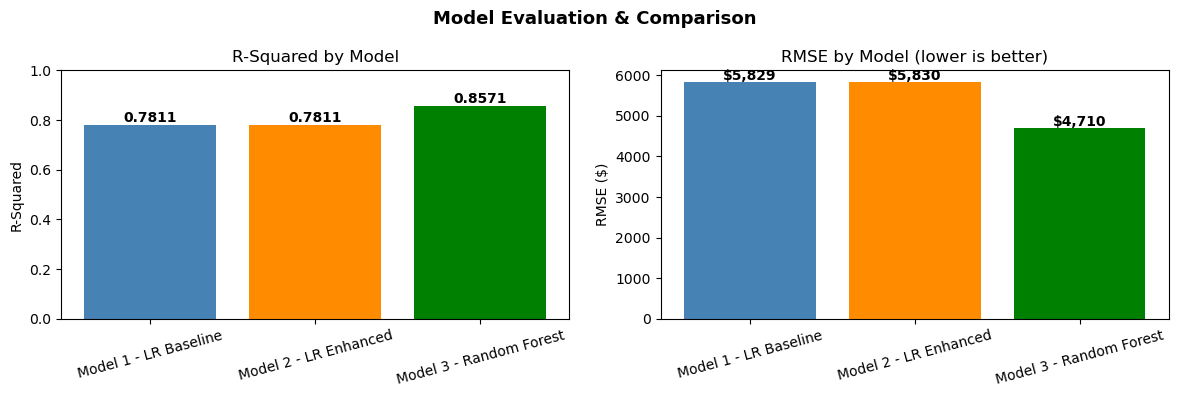

In [251]:
# ───────────────
# Model Comparison Table
# ───────────────

results = pd.DataFrame({
    "Model": ["Model 1 - LR Baseline", "Model 2 - LR Enhanced", "Model 3 - Random Forest"],
    "R_Squared": [r2_1, r2_2, r2_3],
    "RMSE": [rmse_1, rmse_2, rmse_3]
}).round(4)

print("\n=== Model Comparison Table ===")
print(results.to_string(index=False))
print(f"\nBest Model: {results.loc[results['R_Squared'].idxmax(), 'Model']}")

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Evaluation & Comparison", fontsize=13, fontweight="bold")

axes[0].bar(results["Model"], results["R_Squared"],
            color=["steelblue", "darkorange", "green"])
axes[0].set_title("R-Squared by Model")
axes[0].set_ylabel("R-Squared")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(results["R_Squared"]):
    axes[0].text(i, v + 0.01, str(v), ha="center", fontsize=10, fontweight="bold")

axes[1].bar(results["Model"], results["RMSE"],
            color=["steelblue", "darkorange", "green"])
axes[1].set_title("RMSE by Model (lower is better)")
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(results["RMSE"]):
    axes[1].text(i, v + 50, f"${v:,.0f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

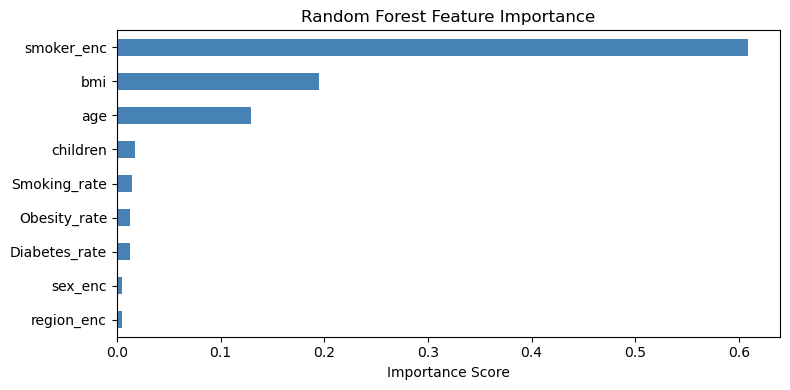


--- Feature Importance Ranking ---
smoker_enc       0.6091
bmi              0.1948
age              0.1294
children         0.0177
Smoking_rate     0.0142
Obesity_rate     0.0122
Diabetes_rate    0.0122
sex_enc          0.0053
region_enc       0.0050


In [252]:
# ───────────────
# Feature Importance
# ───────────────

importances = pd.Series(
    model3.feature_importances_, index=features_3
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="steelblue")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\n--- Feature Importance Ranking ---")
print(importances.sort_values(ascending=False).round(4).to_string())


--- Top 5 Overpriced States (paying more than predicted) ---
State
Maine             4505.05
Indiana           1641.42
Nebraska           622.69
North Carolina     472.80
Kentucky           462.09

--- Top 5 Underpriced States (paying less than predicted) ---
State
Alabama      -1332.57
New Jersey   -1673.67
Vermont      -1830.17
Colorado     -2352.10
New Mexico   -2529.71


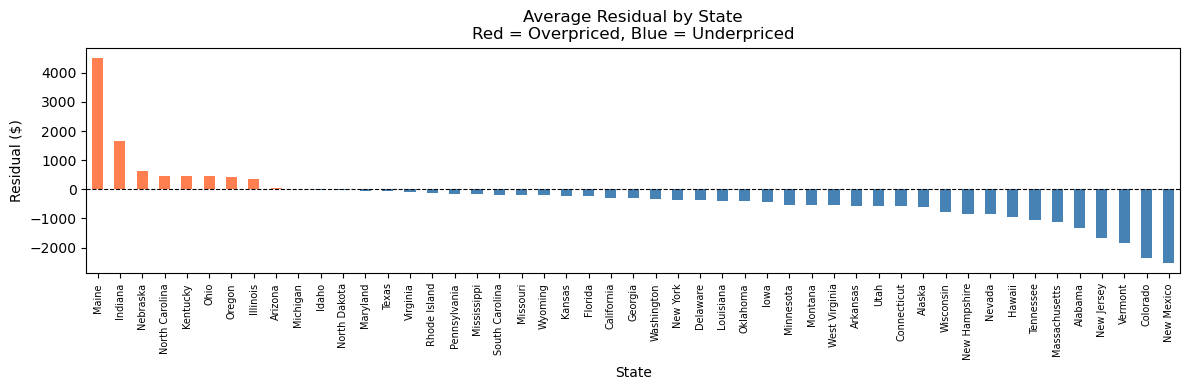

In [127]:
# ───────────────
# Residual Analysis
# ───────────────

df_model["predicted"] = model3.predict(df_model[features_3])
df_model["residual"]  = df_model["charges"] - df_model["predicted"]

residuals_by_state = df_model.groupby("State")["residual"].mean().sort_values(ascending=False)

print("\n--- Top 5 Overpriced States (paying more than predicted) ---")
print(residuals_by_state.head(5).round(2).to_string())

print("\n--- Top 5 Underpriced States (paying less than predicted) ---")
print(residuals_by_state.tail(5).round(2).to_string())

plt.figure(figsize=(12, 4))
colors = ["coral" if x > 0 else "steelblue" for x in residuals_by_state]
residuals_by_state.plot(kind="bar", color=colors)
plt.title("Average Residual by State\nRed = Overpriced, Blue = Underpriced")
plt.xlabel("State")
plt.ylabel("Residual ($)")
plt.xticks(rotation=90, fontsize=7)
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()